In [1]:
import random
import numpy as np

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("karaikal.csv")
df = df.sort_values("time")

df["time"] = pd.to_datetime(df["time"])

In [4]:
feature_cols = [
    "temperature",
    "dewpoint",
    "pressure",
    "wind_u",
    "wind_v",
    "cloud_cover",
    "humidity"
]

target_col = "rain_mm"

X_raw = df[feature_cols]
y_raw = df[[target_col]]


In [5]:
feature_scaler = StandardScaler()
target_scaler  = StandardScaler()

X_scaled = feature_scaler.fit_transform(X_raw)
y_scaled = target_scaler.fit_transform(y_raw)

In [6]:
sequence_length = 12  # 12 timesteps = 72 hours

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (7292, 12, 7)
y shape: (7292, 1)


In [7]:
split_index = int(len(X_seq) * 0.8)

X_train = X_seq[:split_index]
X_test  = X_seq[split_index:]

y_train = y_seq[:split_index]
y_test  = y_seq[split_index:]


In [8]:
model = Sequential([
    Input(shape=(sequence_length, len(feature_cols))),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.8738 - mae: 0.3354 - val_loss: 1.3588 - val_mae: 0.3192
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8648 - mae: 0.3263 - val_loss: 1.3561 - val_mae: 0.3280
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8589 - mae: 0.3246 - val_loss: 1.3521 - val_mae: 0.3191
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8585 - mae: 0.3247 - val_loss: 1.3502 - val_mae: 0.3236
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8560 - mae: 0.3223 - val_loss: 1.3483 - val_mae: 0.3187
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8530 - mae: 0.3226 - val_loss: 1.3495 - val_mae: 0.3242
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8517 - mae: 0.3228 - val_loss: 1.3485 - val_mae: 0.3190
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8506 - mae: 0.3220 - val_loss: 1.3464 - val_mae: 0.3210
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8462 -

In [10]:
y_pred_scaled = model.predict(X_test)

# Inverse transform
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test)

# Clip negative rainfall
y_pred = np.clip(y_pred, 0, None)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [11]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error
)

mse   = mean_squared_error(y_true, y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_true, y_pred)
medae = median_absolute_error(y_true, y_pred)
r2    = r2_score(y_true, y_pred)

print("\nDetailed LSTM Evaluation Metrics")
print("R²     :", round(r2, 4))
print("MSE    :", round(mse, 4))
print("RMSE   :", round(rmse, 4))
print("MAE    :", round(mae, 4))
print("MedAE  :", round(medae, 4))


Detailed LSTM Evaluation Metrics
R²     : 0.0336
MSE    : 0.1877
RMSE   : 0.4333
MAE    : 0.1195
MedAE  : 0.0352


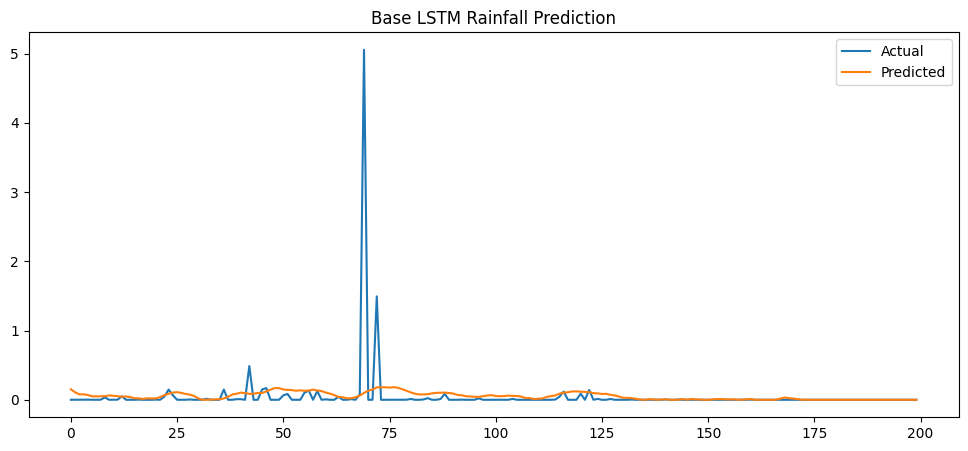

In [12]:
plt.figure(figsize=(12,5))
plt.plot(y_true[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("Base LSTM Rainfall Prediction")
plt.show()

In [13]:

latest_sequence_raw = X_raw.tail(sequence_length)

latest_sequence_scaled = feature_scaler.transform(latest_sequence_raw)

latest_sequence_scaled = latest_sequence_scaled.reshape(1, sequence_length, len(feature_cols))

pred_scaled = model.predict(latest_sequence_scaled)

pred_real = target_scaler.inverse_transform(pred_scaled)

pred_real = np.clip(pred_real, 0, None)

print("\nPredicted Rainfall for Next Time Step:")
print(f"{pred_real[0][0]:.4f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Predicted Rainfall for Next Time Step:
0.1618 mm
